# Training check

## Imports



In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass, field
import seaborn as sns
from performance_boosting import PBClosedLoop
from ren import ContractiveREN
from robot import RobotPlant, StabilizedRobot, PDController
from plot_functions import plot_pb_trajectories
from dataset import generate_random_batch
from losses_and_wrappers import PBLoss, SplitCVaRLossWrapper
from training_function import train_agent
from wakepy import keep

## Simulation parameters

In [ ]:
@dataclass
class ExperimentConfig:
    # --- 1. General Setup ---
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    seed: int = 4

    # --- 2. Dataset Parameters ---
    noise_std: float = 0.0

    # --- 3. Physics & Dynamics Parameters ---
    n_agents: int = 1
    state_dim: int = 4
    input_dim: int = 2
    dt: float = 0.05

    b_nom: float = 1.0
    m_nom: float = 1.0
    b2_nom: float = 0.2

    b_sim: float = 1.0
    m_sim: float = 1.0
    b2_sim: float = 0.2

    # --- 4. REN and Base Controller Parameters ---
    initialization_std: float = 0.01
    dim_internal: int = 4
    dim_nl: int = 4
    kp: float = 1.0
    ki: float = 1.0

    # --- 5. Loss & Cost Parameters ---
    lambda_x: float = 10.0
    lambda_u: float = 0.0
    lambda_decoupling: float = 1.0 # redundant with lambda_obs
    lambda_obs: float = 200.0
    tau_safe_bar: float = 0.0 # only used in lagrangian formulation
    track_mode: str = 'quadratic'
    coll_mode: str = 'rbf'

    # --- 6. Wrapper & Certification Parameters ---
    decoupled_metrics: bool = True # not used
    conditional_training: bool = False
    alpha_true: float = 0.05
    delta: float = 0.01
    m_cert: int = 2000 # TODO: think about adapating later using Piga's upper/lower bounds

    # --- 7. Training & Validation Parameters ---
    num_training_steps: int = 200
    n_inner_steps: int = 5
    log_interval: int = 1
    early_stopping_patience_limit: int = None
    gradient_clipping: float = None
    batch_size: int = 200
    horizon: int = 500
    lr: float = 0.001
    num_val_samples: int = 500
    num_test_samples: int = 2000

    # ==========================================
    # Computed / Dependent Variables
    # ==========================================
    # These are calculated automatically upon initialization
    def __post_init__(self):
        # Setup Distribution
        self.x0_centers = [[-1.0, -1.0], [1.0, -1.0], [1.0, 1.5]]
        self.x0_stds = [0.2, 0.1, 0.4]
        self.x0_probs = [0.6, 0.2, 0.2]

        # Setup Loss Matrices (Q and R)
        self.Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * self.lambda_x
        self.Q = torch.kron(torch.eye(self.n_agents), self.Q_agent).to(self.device)

        self.R_agent = torch.eye(2) * self.lambda_u
        self.R = torch.kron(torch.eye(self.n_agents), self.R_agent).to(self.device)

        # Setup Obstacles
        self.obs_centers = [torch.tensor([0.5, -0.5]).to(self.device)]
        self.obs_radii = [[0.8, 0.15]]
        self.safety_margin = 0.05 # not used with rbf loss
        self.obs_radii_safe = [[r + self.safety_margin for r in obs] for obs in self.obs_radii] # not used with rbf loss

        # Setup Target
        self.x_target = torch.zeros(4 * self.n_agents).to(self.device)

        # Calculate Training Alpha
        if self.conditional_training:
            self.epsilon_cert = np.sqrt(np.log(2 / self.delta) / (2 * self.m_cert))
        else:
            self.epsilon_cert = 0.0
        self.alpha_train = self.alpha_true - self.epsilon_cert

config = ExperimentConfig()
# Setup plotting arguments
my_plot_kwargs = {
    'plot_func': plot_pb_trajectories,
    'x_target': config.x_target,
    'obs_centers': config.obs_centers,
    'obs_radii': config.obs_radii,
    'obs_radii_safe': config.obs_radii_safe,
    'dt': config.dt
}

## Fixed validation and test set

In [4]:
# Fixed validation set
fixed_val_w = generate_random_batch(config, custom_batch_size=config.num_val_samples)
# Fixed test set
test_w = generate_random_batch(config, custom_batch_size=config.num_test_samples)

## Simulator, nominal model and stabilizing controller

In [5]:
#Open loop real plant (unknown)
sim_OL_plant = RobotPlant(b = config.b_sim, b2 = config.b2_sim, m = config.m_sim, n_agents = config.n_agents).to(config.device)
#Open loop nominal model
nominal_OL_plant = RobotPlant(b = config.b_nom, b2 = config.b2_nom, m = config.m_nom, n_agents = config.n_agents).to(config.device)
#Proportional controller
base_controller = PDController(kp = config.kp, ki = config.ki, n_agents = config.n_agents).to(config.device)
#Stabilized real plant (closed loop of real plant and base controller) (unknown)
f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(config.device)
#Stabilized nominal model (closed loop of nominal model and base controller) (I could use a different controller as long as this is a stable closed loop or if I use the base controller of the real plant I have to make sure it stabilizes my model as well)
f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(config.device)

#Freeze the physics/nominal models
for param in f_sim.parameters():
    param.requires_grad = False
for param in f_nom.parameters():
    param.requires_grad = False

## Loss function

In [6]:
# Instantiate the base metric
metric = PBLoss(
    x_target=config.x_target,
    Q=config.Q,
    R=config.R,
    lambda_obs=config.lambda_obs,
    obs_centers=config.obs_centers,
    obs_radii_safe=config.obs_radii_safe,
    n_agents=config.n_agents,
    track_mode=config.track_mode,
    coll_mode=config.coll_mode
)
metric.to(config.device)


PBLoss()

# CVaR training

### Define simulated model

In [7]:
#Ren
ren_cvar = ContractiveREN(dim_in=config.state_dim*config.n_agents, dim_out=config.input_dim*config.n_agents, dim_internal=config.dim_internal, dim_nl=config.dim_nl, initialization_std=config.initialization_std).to(config.device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_cvar = PBClosedLoop(ren_cvar, f_sim, f_nom).to(config.device)

### Training loop

Starting STANDARD_CVAR online training on cpu...


Standard Cvar: 100%|██████████| 200/200 [01:27<00:00,  2.29it/s, Val Loss=1.7618, Best=1.7457] 



Restored best model (Metric: 1.7457).


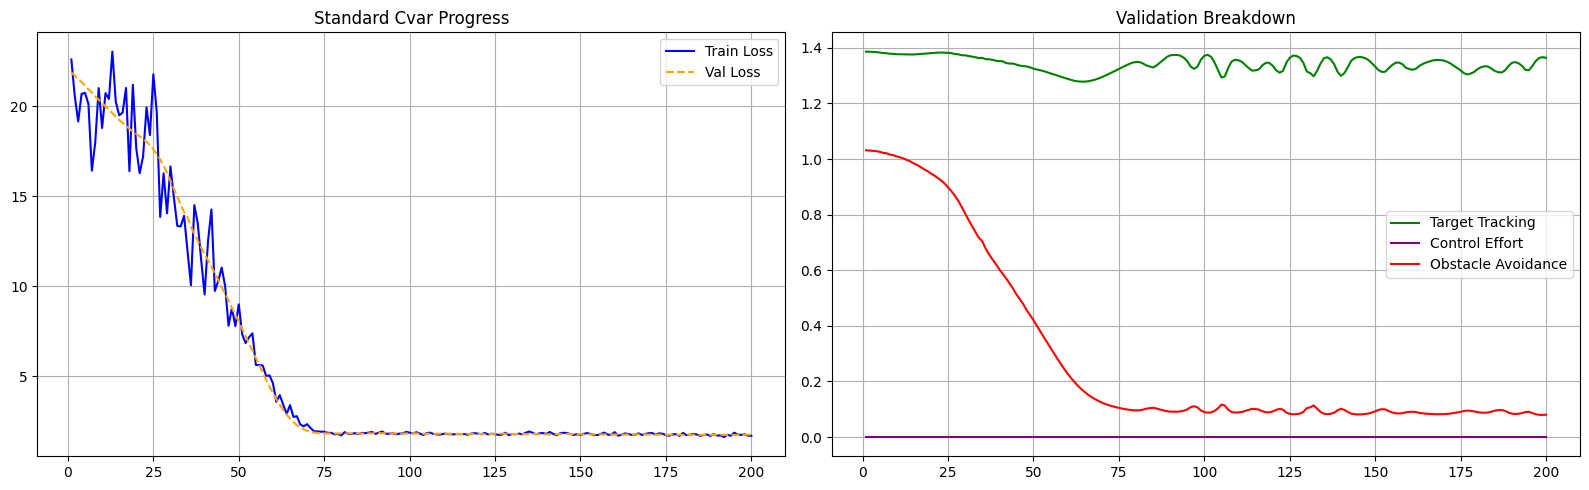

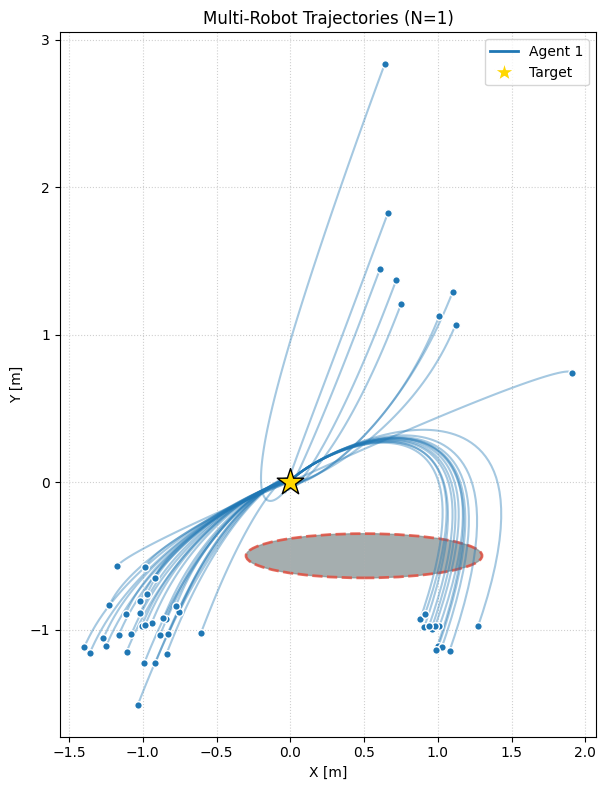

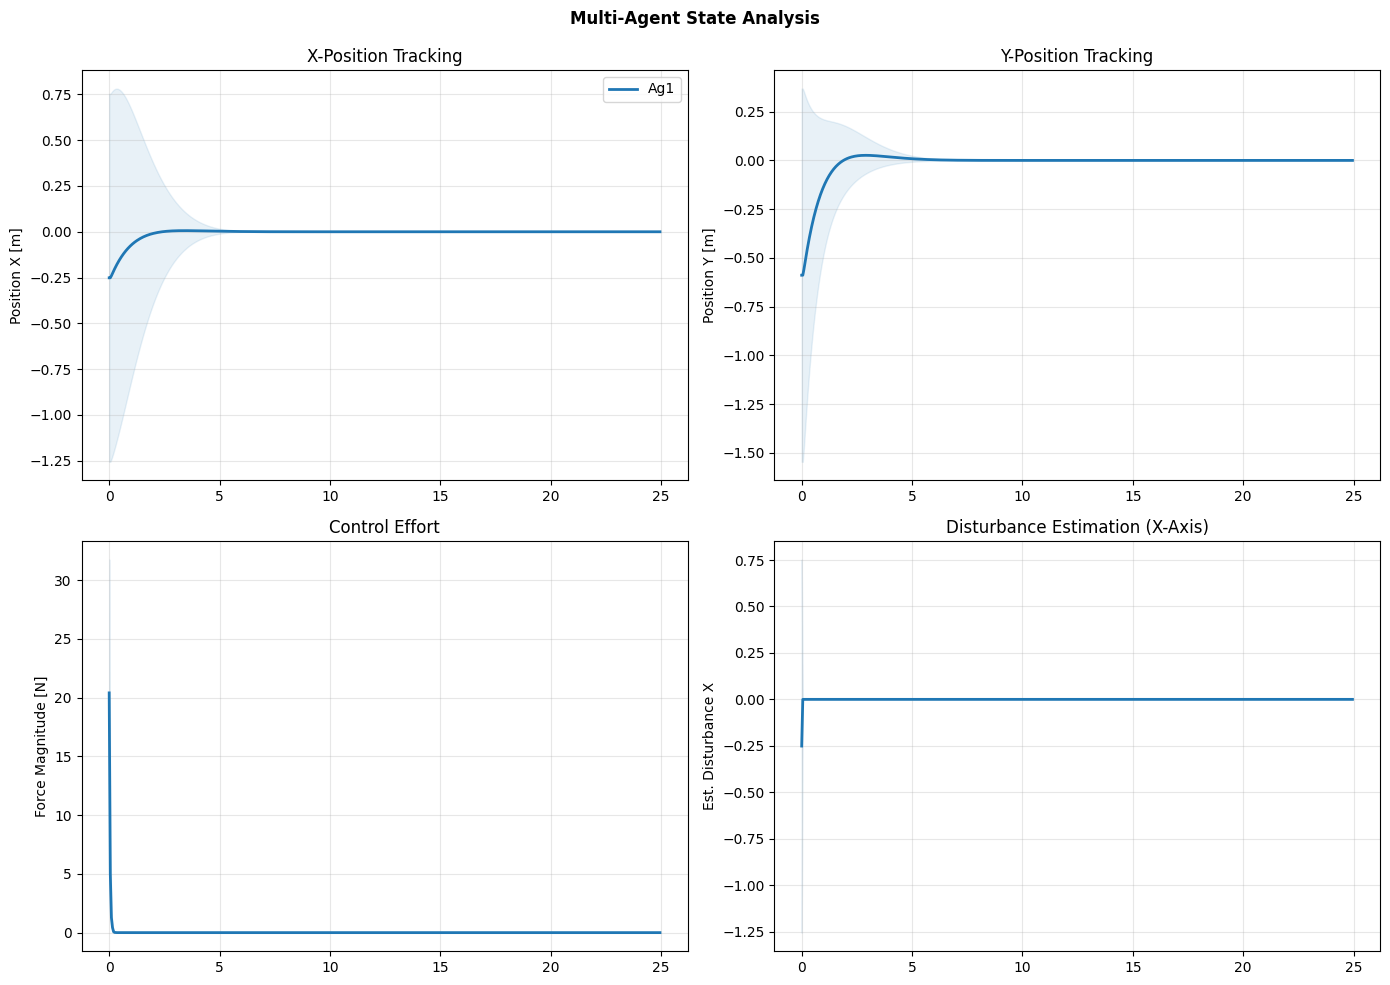

In [8]:
# Use SplitCVaRLossWrapper if decoupled_metrics is True, else CVaRLossWrapper
cvar_wrapper = SplitCVaRLossWrapper(alpha=config.alpha_train, metric=metric, lambda_decoupling=config.lambda_decoupling)
cvar_wrapper.to(config.device)

with keep.presenting():
    history_std_cvar, trajs_std_cvar = train_agent(
        config=config,
        sim=PB_closed_loop_sim_cvar,
        loss_wrapper=cvar_wrapper,
        mode="standard_cvar", # as opposed to lagrangian_cvar
        fixed_val_w=fixed_val_w,
        generate_random_batch=generate_random_batch,
        plot_results=True,
        plot_kwargs=my_plot_kwargs
    )

## Verification

Mean performance (Q+R) on validation set: 1.319557
Maximum-violation quantile on validation set @ q=0.950: 0.197982
Validation violation rate (maximum violation > 0): 20.20%


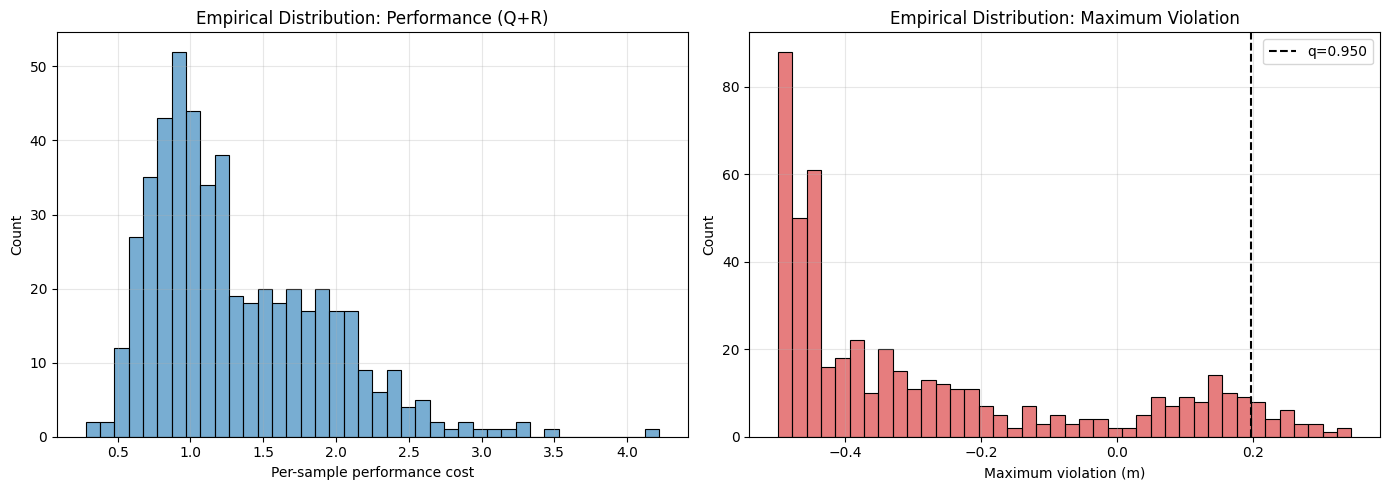

In [15]:
# Verification block: empirical performance and safety statistics on the validation set
with torch.no_grad():
    traj_x_val, traj_u_val, _ = PB_closed_loop_sim_cvar.run(fixed_val_w)
    _, cost_x_val, cost_u_val, _ = metric(traj_x_val, traj_u_val)

# Per-sample performance term = tracking (Q) + actuation (R)
perf_qr_val = cost_x_val + cost_u_val
mean_perf_qr = perf_qr_val.mean().item()

# Maximum-violation score for safety: positive inside obstacle, negative outside
x_val_reshaped = traj_x_val.view(traj_x_val.shape[0], traj_x_val.shape[1], config.n_agents, 4)
pos_val = x_val_reshaped[..., :2]  # [B, H, N, 2]

obs_centers_t = torch.stack(config.obs_centers).to(config.device)                    # [O, 2]
obs_radii_safe_t = torch.tensor(config.obs_radii_safe, dtype=torch.float32, device=config.device)  # [O, 2]

# Broadcast to [B, H, N, O, 2]
centers = obs_centers_t.view(1, 1, 1, -1, 2)
diff = pos_val.unsqueeze(3) - centers
r_safe = obs_radii_safe_t.view(1, 1, 1, -1, 2)

# 1) Intersect ray (center -> position) with safe ellipsoid border
eps = 1e-12
rho = torch.linalg.norm(diff / (r_safe + eps), dim=-1)                 # normalized radius
rho_safe = torch.clamp(rho, min=eps)
border_point = centers + diff / rho_safe.unsqueeze(-1)                  # [B, H, N, O, 2]

# 2) Euclidean distance from position to that border point, signed by inside/outside
unsigned_dist = torch.linalg.norm(pos_val.unsqueeze(3) - border_point, dim=-1)
signed_dist = torch.where(rho < 1.0, unsigned_dist, -unsigned_dist)     # inside:+, outside:-

# Robust handling at exact obstacle center (rho ~ 0): distance is positive
min_safe_radius = r_safe.min(dim=-1).values.expand_as(signed_dist)
signed_dist = torch.where(rho < 1e-9, min_safe_radius, signed_dist)

# One score per trajectory: maximum violation over time/agents/obstacles
maximum_violation = signed_dist.amax(dim=(1, 2, 3))

# Upper-tail quantile is the relevant quantile for maximum-violation scores
maximum_violation_quantile_level = 1.0 - config.alpha_true
maximum_violation_quantile = torch.quantile(maximum_violation, maximum_violation_quantile_level).item()

# Fraction of trajectories violating the safety border (maximum violation > 0)
violation_rate = (maximum_violation > 0.0).float().mean().item()

print(f"Mean performance (Q+R) on validation set: {mean_perf_qr:.6f}")
print(
    f"Maximum-violation quantile on validation set @ q={maximum_violation_quantile_level:.3f}: "
    f"{maximum_violation_quantile:.6f}"
)
print(f"Validation violation rate (maximum violation > 0): {violation_rate:.2%}")

# Plot empirical distributions (counts)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    perf_qr_val.detach().cpu().numpy(), bins=40, stat='count',
    ax=axes[0], color='tab:blue', alpha=0.6
)
axes[0].set_title('Empirical Distribution: Performance (Q+R)')
axes[0].set_xlabel('Per-sample performance cost')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

sns.histplot(
    maximum_violation.detach().cpu().numpy(), bins=40, stat='count',
    ax=axes[1], color='tab:red', alpha=0.6
)
axes[1].axvline(maximum_violation_quantile, color='black', linestyle='--', label=f"q={maximum_violation_quantile_level:.3f}")
axes[1].set_title('Empirical Distribution: Maximum Violation')
axes[1].set_xlabel('Maximum violation (m)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()